# Модель для предсказания массы морских черепах



    Выполнила: Альбина Тулянцева
    Дата: 21.03.2026
    Каждый год «Тортилла» спасает десятки особей, пострадавших от рыболовных сетей, столкновений с лодками, болезней и загрязнения среды обитания пластиком. Чтобы провести черепахам реабилитацию и затем выпустить их обратно в океан, критически важно точно знать массу каждой из них.
    Традиционное взвешивание крупной, активной, а иногда травмированной морской черепахи — это огромный стресс для животного и риск для персонала.
    Партнёры центра «Тортилла» из «Лаборатории перспективных технологий института океанографии» разработали портативную систему компьютерного зрения TurtleCV, которая будет с высокой точностью бесконтактно измерять габариты черепах, пока те находятся в реабилитационных бассейнах или на мелководье в естественной среде обитания.

    Цель - разработать модель линейной регрессии, которая будет использовать габариты и другие данные от TurtleCV для предсказания массы черепах.
    
    Задачи:
    - Загрузить датасет
    - Изучить данные и произвести исследовательских анализ
    - Сделать предобработку
    - Обучить модель
    - Сравнить модель на валидационной выборке
    - Проверить лучшую модель на тестовой выборке
    - Оценить важности признаков
    - Создать функцию для прогнозирования веса черепахи
    - Составить выводы
    
    Данные: 
    id — идентификатор измерения.
    binomial_name — международное научное название вида черепахи.
    registration_number — регистрационный номер черепахи.
    shell_length — длина панциря, мм.
    shell_width — ширина панциря, мм.
    head_length — длина головы, мм.
    head_width — ширина головы, мм.
    flipper_length_n — длина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
    flipper_width_n — ширина одной ласты, мм. У черепах четыре ласты, поэтому в датасете четыре таких столбца, в названиях вместо n указан номер от 1 до 4.
    circle_count — количество колец роста на панцире черепахи.
    measure_count — количество измерений, которые произвели, прежде чем усреднить показатели черепахи и добавить их в таблицу.
    shell_crack — наличие трещин панциря.
    timestamp — время внесения данных о черепахе.
    weight — масса черепахи, кг.

## Постановка задачи машинного обучения

- Опишите, какую задачу нужно решить: регрессии или классификации.
- Выберите поле, которое станет целевой переменной.
- Назовите метрики качества модели, которые планируете использовать.
- Опишите критерии успешности проекта с опорой на метрики.

    Для решения задачи нужно использовать регрессию. Для поставленной задачи подойдёт классика — библиотека scikit-learn и подходящие для регрессии модели: LinearRegression, Lasso, Ridge, SGDREgressor. 
    Целевой переменной станет weight - масса черепахи.
    В этом проекте основная метрика качества уже определена в задании. Она нужна, чтобы подобрать гиперпараметры, сравнить модели и выбрать кандидата для внедрения. Чем ближе к идеальному значению основной метрики, тем лучше модель подходит для внедрения в эксплуатацию. В качестве основной будем использовать MAE, дополнительными будут MSE, R², MAPE. Стоит посмотреть, какие значения каждая из них покажет на разных моделях.
    По заданию MAE лучшей модели должна быть не больше 5 килограмм.Если и на тестовой выборке метрика MAE не больше 5 килограмм, то модель можно рекомендовать к внедрению. Она докажет, что прошла все испытания, достигнув нужной планки основной метрики без утечки.

## Подключение и настройка библиотек

В блоке кода ниже, помимо уже указанных библиотек, импортируйте все остальные, которые планируете использовать для проекта.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

#импорт моделей
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import LassoCV
from sklearn.dummy import DummyRegressor

#импорт масштабирования
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#импорт метрик
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score

#импорт phik
!pip install phik -q
from phik import phik_matrix

#Задаем константу
RANDOM_STATE = 42

## Загрузка датасета

- Загрузите данные из файла `turtles.csv`, путь к файлу: `'/datasets/turtles.csv'`. При использовании метода [read_csv](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.read_csv.html) установите правильные значения для параметров `sep` и `decimal`: в качестве разделителя столбцов используйте символ табуляции (`'\t'`), а в качестве разделителя дробной части — запятую.
- Проверьте, правильно ли прошла загрузка. Данные должны соответствовать описанию в тексте урока.
- С помощью методов библиотеки pandas выведите общие сведения о данных.
- Возможно ли продолжать работу? Если нет — что нужно сделать, чтобы устранить препятствия?

In [2]:
#загрузка датасета
df = pd.read_csv('/datasets/turtles.csv', sep='\t', decimal=',')
print(df.head(5))

      id          binomial_name               registration number  \
0  20438        Caretta caretta  d89af72662f49ece4d09dec75a8b0166   
1  19034  Lepidochelys olivacea  1579c64777de4db1c16e8b7b0d19c45e   
2  24689  LEPIDOCHELYS OLIVACEA  bfcec01187569615087e4d777c44985a   
3  17945  Lepidochelys Olivacea  2c159675aa28f0ea566fce2090bf4c82   
4  24543  lepidochelys olivacea  ecd22499761e2ac56a6d8eb765ec566d   

   shell_length  shell_width  head_length  head_width  flipper_length_1  \
0         700.0          381        112.0        82.0               356   
1         341.0          295         65.0        48.0               216   
2         408.0          343         71.0        70.0               308   
3         512.0          432         98.0        95.0               334   
4         408.0          307         50.0        54.0               280   

   flipper_width_1  flipper_length_2  flipper_width_2  flipper_length_3  \
0              205               331              185      

**3.1 Общие сведения о данных**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8861 entries, 0 to 8860
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   8861 non-null   int64  
 1   binomial_name        8812 non-null   object 
 2   registration number  8832 non-null   object 
 3   shell_length         8774 non-null   float64
 4   shell_width          8861 non-null   int64  
 5   head_length          8715 non-null   float64
 6   head_width           8715 non-null   float64
 7   flipper_length_1     8861 non-null   int64  
 8   flipper_width_1      8861 non-null   int64  
 9   flipper_length_2     8861 non-null   int64  
 10  flipper_width_2      8861 non-null   int64  
 11  flipper_length_3     8760 non-null   float64
 12  flipper_width_3      8760 non-null   float64
 13  flipper_length_4     8760 non-null   float64
 14  flipper_width_4      8760 non-null   float64
 15  circle_count         8861 non-null   i

In [4]:
df.describe()

,id,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,measure_count,shell_crack,timestamp,weight
count,8861.000000,8774.000000,8861.000000,8715.000000,8715.000000,8861.000000,8861.000000,8861.000000,8861.000000,8760.000000,8760.000000,8760.000000,8760.000000,8861.000000,8597.000000,2176.000000,8.861000e+03,8842.000000
mean,21359.335628,764.222020,598.832299,123.341021,115.735169,497.551405,380.594515,498.228530,380.687507,397.953196,304.405251,397.853196,305.030023,41.002821,2.477143,1.671415,1.712640e+09,79.163138
std,2263.089420,640.408681,480.970492,67.836566,62.326365,353.575213,214.481679,355.074883,213.485239,282.970532,171.172490,281.983591,171.540535,36.995874,1.116564,1.131790,2.292273e+07,95.877609
min,17438.000000,132.000000,78.000000,19.000000,12.000000,60.000000,34.000000,57.000000,33.000000,50.000000,27.000000,44.000000,25.000000,0.000000,1.000000,1.000000,1.672570e+09,0.000000
25%,19396.000000,440.000000,341.000000,73.000000,67.000000,296.000000,228.000000,296.000000,229.000000,239.000000,182.000000,236.000000,183.000000,0.000000,1.000000,1.000000,1.693001e+09,31.109500
50%,21357.000000,635.000000,487.000000,106.000000,98.000000,416.000000,332.000000,417.000000,330.000000,333.000000,264.000000,333.000000,266.000000,35.000000,2.000000,1.000000,1.712804e+09,41.140500
75%,23317.000000,951.000000,794.000000,158.000000,156.000000,571.000000,493.000000,572.000000,500.000000,457.000000,397.000000,456.000000,396.000000,73.000000,3.000000,2.000000,1.732902e+09,85.239500
max,25279.000000,20240.000000,11550.000000,515.000000,382.000000,2875.000000,1479.000000,2967.000000,1402.000000,2279.000000,1280.000000,2406.000000,1313.000000,178.000000,4.000000,5.000000,1.751608e+09,617.777000


    В данных присутствуют пропуски. Пропуски есть в 12 столбцах из 20. В дальнейшем придется очистить данные от пропусков, чтобы они не мешали обучению модели.
    В столбце shell_length наблюдается аномально большие значения. Заказчик предупреждал, что некоторые значения длины были умножены на 10. Проведем дополнительный анализ и устраним выбросы.

**3.2 Исправление ошибки в данных**

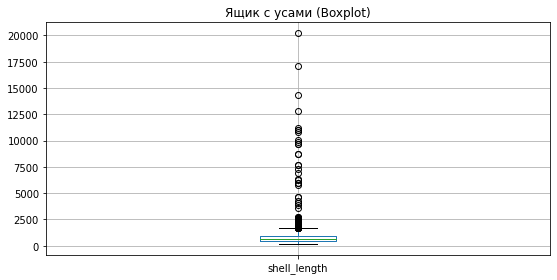

In [5]:
plt.figure(figsize=(15, 4))

#ящик с усами
plt.subplot(1, 2, 2)
df.boxplot(column='shell_length')
plt.title('Ящик с усами (Boxplot)')

plt.tight_layout()
plt.show()

На графике видно, что в данных есть большое количество аномальных выбросов, которые скорее всего произошли из-за ошибки сбора данных. Исходя из средних данных по черепахам, длина панциря не может превышать 3000мм, поэтому все значения выше этого числа будем делить на 10.

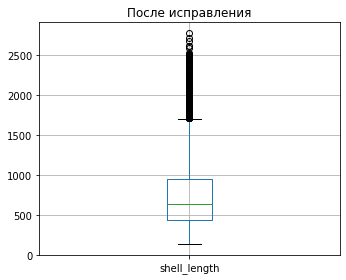

In [6]:
#фильтруем
mask = df['shell_length'] > 3000

# Делим их на 10
df.loc[mask, 'shell_length'] = df.loc[mask, 'shell_length'] / 10

#визуализируем

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 2)
df.boxplot(column='shell_length')
plt.title('После исправления')

plt.tight_layout()
plt.show()

После деления выбросов можно заметить, что сохранились выбросы, но теперь они не мешают смотреть на основную группу данных

## Исследовательский анализ данных

Проведите исследовательский анализ данных:
1. Выясните, данные о каких черепахах представлены в датасете.
2. Проведите отбор записей о нужном виде черепах. Для дальнейшей работы достаточно изучить только *Chelonia mydas*. При этом вы можете сравнить распределение данных об этих черепахах с другими видами, если есть желание и время.
3. Определите, все ли признаки можно использовать для решения задачи. Ответ обоснуйте. Удалите признаки, которые вам никак не помогут.
4. Проверьте, есть ли в данных пропуски. Определите, какие из них можно обработать сразу, а в каких случаях лучше сперва провести разделение на выборки. Решите, стоит ли удалить некоторые пропуски.
5. Определите, есть ли в данных дубликаты. Выберите корректный способ их обработки.
6. Проанализируйте распределение признаков, постройте необходимые для этого визуализации: ящики с усами, гистограммы и так далее. Определите, есть ли в данных выбросы и какие из них критичные. Решите, можно ли их сразу исправить.
7. Проверьте, одинаков ли масштаб признаков. Если он различается, предложите решение этой проблемы.
8. Проанализируйте корреляцию между признаками и целевой переменной с помощью вычислений и графически. Определите, все ли признаки нужны для дальнейшей работы.
9. Проверьте данные на мультиколлинеарность и решите, можно ли её устранить.

**4.1 Анализ представленных черепах и отбор нужного вида**

In [7]:
unique_turtles = df['binomial_name'].unique()
print(unique_turtles)

['Caretta caretta' 'Lepidochelys olivacea' 'LEPIDOCHELYS OLIVACEA'
 'Lepidochelys Olivacea' 'lepidochelys olivacea' 'Chelonia mydas'
 'ERETMOCHELYS IMBRICATA' 'Eretmochelys imbricata' 'Dermochelys coriacea'
 'caretta caretta' 'CARETTA CARETTA' 'chelonia mydas' 'Chelonia Mydas'
 'CHELONIA MYDAS' 'Dermochelys Coriacea' 'eretmochelys imbricata' nan
 'Caretta Caretta' 'lepidochelys kempii' 'Lepidochelys kempii'
 'Eretmochelys Imbricata' 'dermochelys coriacea' 'Lepidochelys Kempii'
 'DERMOCHELYS CORIACEA']


In [8]:
#некоторые названия повторяются в другом регистре, приведем всё к нижнему регистру
df['binomial_name'] = df['binomial_name'].str.lower()

unique_turtles = df['binomial_name'].unique()
print(unique_turtles)

['caretta caretta' 'lepidochelys olivacea' 'chelonia mydas'
 'eretmochelys imbricata' 'dermochelys coriacea' nan 'lepidochelys kempii']


In [9]:
#оставляем данные только о Chelonia mydas
species_name = 'chelonia mydas'
df_filtered = df[df['binomial_name'] == species_name]

#посмотрим, как изменился датасет после фильтрации
df_filtered.info()

len_difference = len(df) - len(df_filtered)
print(f'Разница в количестве строк:{len_difference}')

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   2829 non-null   int64  
 1   binomial_name        2829 non-null   object 
 2   registration number  2825 non-null   object 
 3   shell_length         2794 non-null   float64
 4   shell_width          2829 non-null   int64  
 5   head_length          2790 non-null   float64
 6   head_width           2790 non-null   float64
 7   flipper_length_1     2829 non-null   int64  
 8   flipper_width_1      2829 non-null   int64  
 9   flipper_length_2     2829 non-null   int64  
 10  flipper_width_2      2829 non-null   int64  
 11  flipper_length_3     2798 non-null   float64
 12  flipper_width_3      2798 non-null   float64
 13  flipper_length_4     2798 non-null   float64
 14  flipper_width_4      2798 non-null   float64
 15  circle_count         2829 non-null   i

В данных всё также осталось множество столбцов с пропусками, количество строк изменилось с 8861 до 2829(разница - 6032).

**4.2 Удаление ненужных признаков**

Для дальнейшего построения модели не потребуются столбцы 'id'(дается черепахе без причины, может помешать работе модели), 'binomial_name'(так как оно везде одинаковое), 'registration number'(может давать ложную связь), 'measure_count'(кол-во измерений перед внесением данных никак не влияет на уже имеющийся вес черепахи), 'timestamp'(время внесения данных также не влияет), 'shell_crack'(данных слишком мало, это может помешать работе модели, а заполнение средним значением испортит данные)

In [10]:
#удаляем столбцы
columns_to_drop = ['id', 'binomial_name', 'registration number', 'measure_count', 'shell_crack', 'timestamp']

df_filtered = df_filtered.drop(columns=columns_to_drop)

#изучим датасет после удаления столбцов
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2829 entries, 8 to 8859
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2794 non-null   float64
 1   shell_width       2829 non-null   int64  
 2   head_length       2790 non-null   float64
 3   head_width        2790 non-null   float64
 4   flipper_length_1  2829 non-null   int64  
 5   flipper_width_1   2829 non-null   int64  
 6   flipper_length_2  2829 non-null   int64  
 7   flipper_width_2   2829 non-null   int64  
 8   flipper_length_3  2798 non-null   float64
 9   flipper_width_3   2798 non-null   float64
 10  flipper_length_4  2798 non-null   float64
 11  flipper_width_4   2798 non-null   float64
 12  circle_count      2829 non-null   int64  
 13  weight            2826 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 331.5 KB


**4.3 Работа с пропусками**

Сейчас пропуски присутствуют в 8 столбцах из 15: 'shell_length', 'head_length', 'head_width', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'weight'. Большинство пропусков лучше заполнить уже после разделения на выборке, чтобы предотвратить утечку данных. В целевой переменной('weight') присутствуют всего 3 пропуска, поэтому проще удалить эти строки.

In [11]:
#удаление пропусков в weight
df_filtered = df_filtered.dropna(subset=['weight'])

df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2826 entries, 8 to 8859
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2791 non-null   float64
 1   shell_width       2826 non-null   int64  
 2   head_length       2787 non-null   float64
 3   head_width        2787 non-null   float64
 4   flipper_length_1  2826 non-null   int64  
 5   flipper_width_1   2826 non-null   int64  
 6   flipper_length_2  2826 non-null   int64  
 7   flipper_width_2   2826 non-null   int64  
 8   flipper_length_3  2795 non-null   float64
 9   flipper_width_3   2795 non-null   float64
 10  flipper_length_4  2795 non-null   float64
 11  flipper_width_4   2795 non-null   float64
 12  circle_count      2826 non-null   int64  
 13  weight            2826 non-null   float64
dtypes: float64(8), int64(6)
memory usage: 331.2 KB


**4.4 Работа с дубликатами**

In [12]:
#проверка на наличие явных дубликатов
#считаем абсолютное количество дубликатов
len_duplicates = df_filtered.duplicated().sum()
#считаем относительное количество дубликатов
duplicates_ratio = round((len_duplicates/len(df_filtered))*100, 2)

print(f'Абсолютное количество дубликатов:{len_duplicates}')
print(f'Относительное количество дубликатов:{duplicates_ratio}%')

Абсолютное количество дубликатов:340
Относительное количество дубликатов:12.03%


In [13]:
#удаляем дубликаты
df_unique = df_filtered.drop_duplicates()

df_difference = len(df_filtered)-len(df_unique)
df_difference_ratio = round(df_difference/len(df_filtered)*100, 2)

print(f'Количество строк после удаления:{len(df_unique)}')
print(f'Абсолютное количество удаленных строк:{df_difference}')
print(f'Относительное количество удаленных строк:{df_difference_ratio}%')

Количество строк после удаления:2486
Абсолютное количество удаленных строк:340
Относительное количество удаленных строк:12.03%


После удаления явных дубликатов датасет сократился на 340 строк(12,03%). Проверка на неявные дубликаты не проводилась, так как в датасете не осталось тектовых значений, только числовые.

**4.5 Анализ распределения признаков**

Изучим распределение данных в оставшихся признаках. Для этого построим ящик с усами для всех признаков, чтобы проверить их на выбросы.

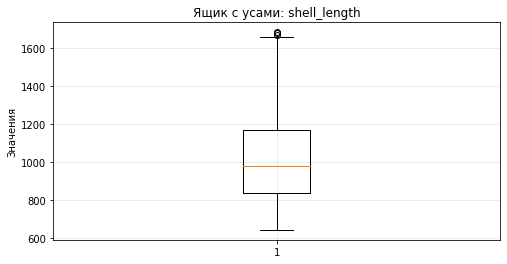

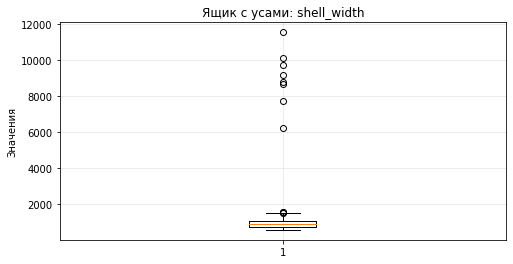

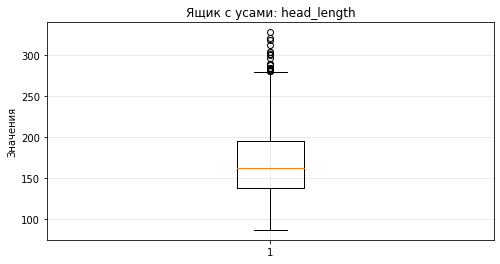

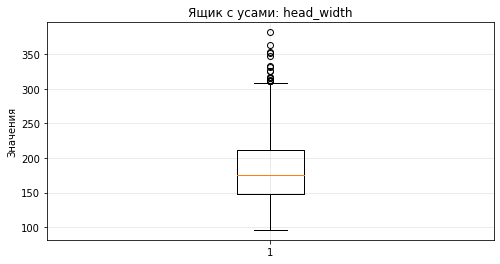

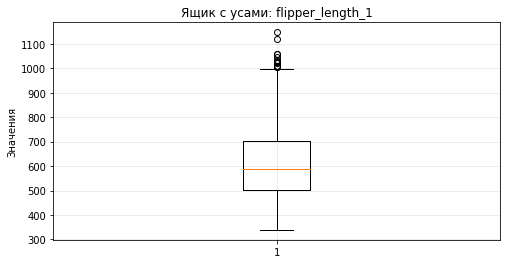

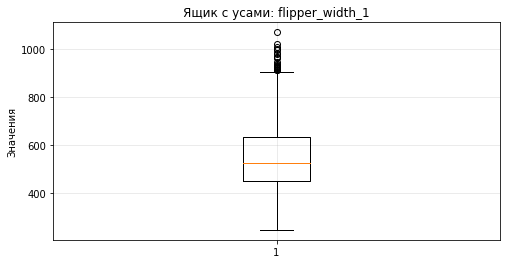

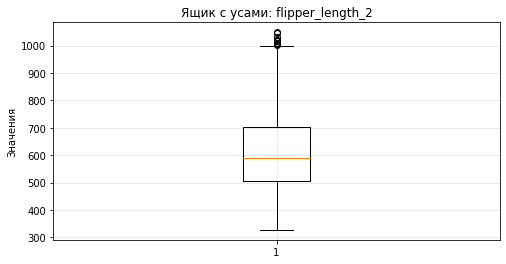

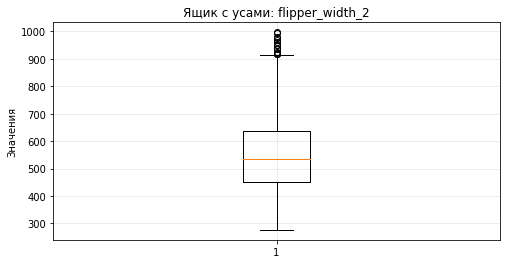

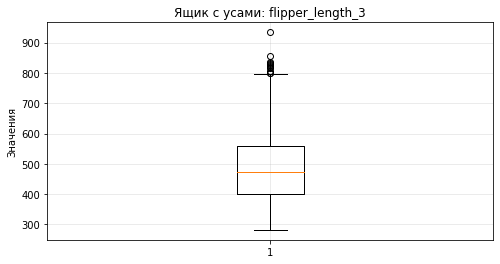

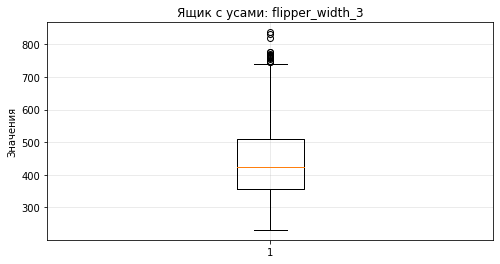

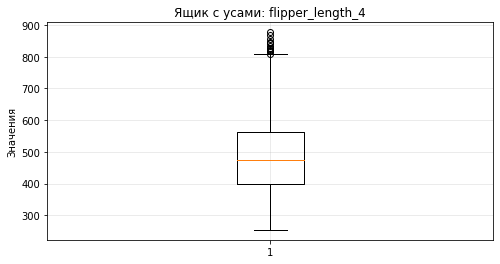

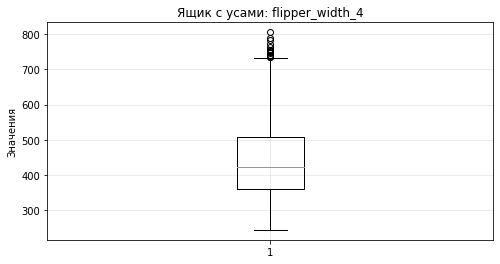

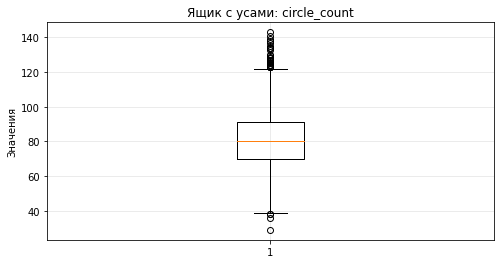

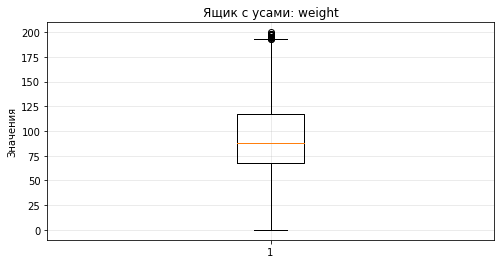

In [14]:
#Строим ящик с усами для всех значений
for column in df_unique.columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df_unique[column].dropna())
    plt.title(f'Ящик с усами: {column}')
    plt.ylabel('Значения')
    plt.grid(True, alpha=0.3)
    plt.show()

Очень большие выбросы наблюдаются в столбце shell_width. Такие аномальные значения могут очень сильно помешать работе модели, поэтому данные нужно отсортировать по 99-му персентилю. Проведем сортировку после разделения на выборки.

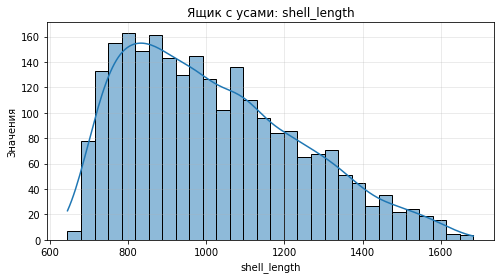

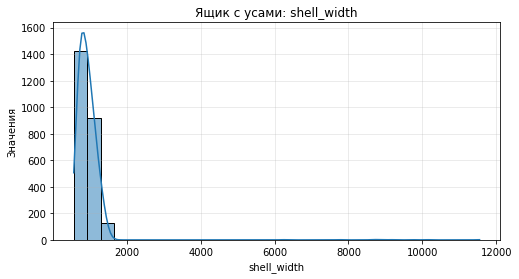

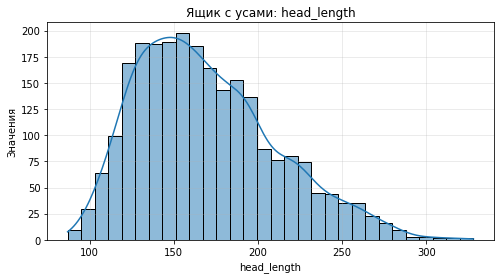

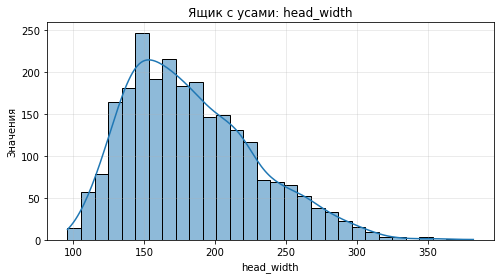

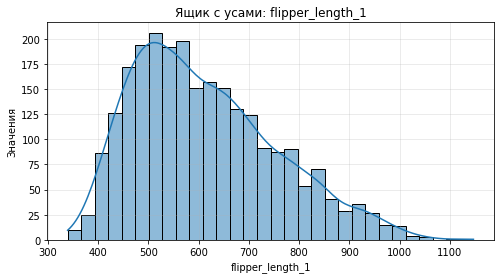

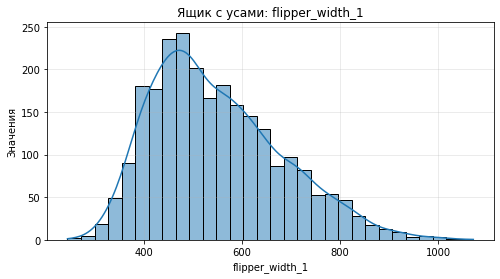

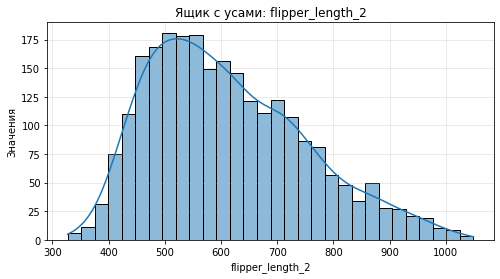

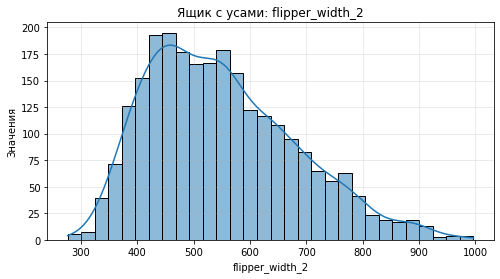

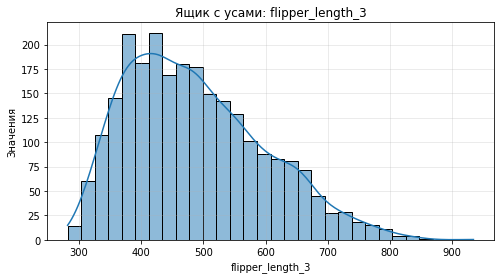

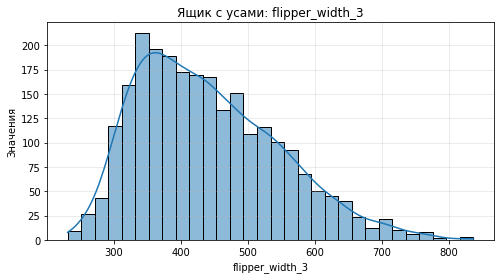

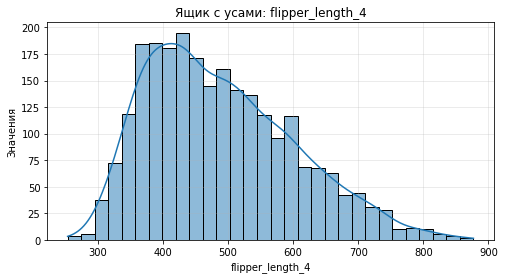

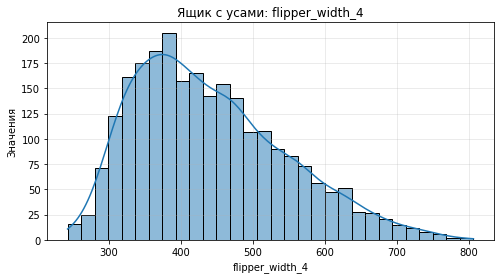

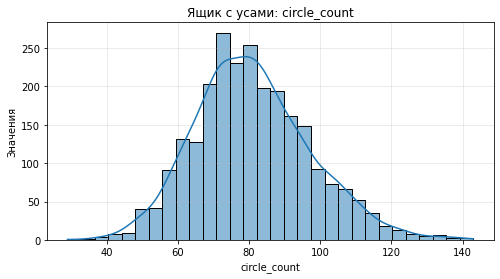

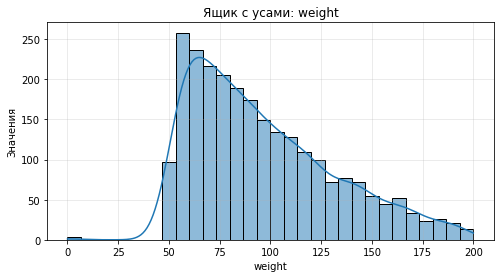

In [15]:
#Строим гистрограмму для дополнительной проверки
for column in df_unique.columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_unique[column].dropna(), kde=True, bins=30)
    plt.title(f'Ящик с усами: {column}')
    plt.ylabel('Значения')
    plt.grid(True, alpha=0.3)
    plt.show()

Остальные столбцы имеют нормальное количество выбросов, поэтому их можно оставить без сортировки.

**4.6 Проверка масштабов признаков**

Для проверки масштабов посмотрим, каких значений достигают признаки.

In [16]:
df_unique.describe()

,shell_length,shell_width,head_length,head_width,flipper_length_1,flipper_width_1,flipper_length_2,flipper_width_2,flipper_length_3,flipper_width_3,flipper_length_4,flipper_width_4,circle_count,weight
count,2457.000000,2486.000000,2451.000000,2451.000000,2486.000000,2486.000000,2486.000000,2486.000000,2457.000000,2457.000000,2457.000000,2457.000000,2486.000000,2486.000000
mean,1018.436304,945.018101,169.723378,183.321093,612.010459,549.364441,611.890185,550.253017,487.262922,440.667481,489.176231,440.975173,80.931617,96.068853
std,222.149470,507.521189,41.335454,45.477540,142.589526,131.859104,138.991986,130.856316,110.435270,105.532073,112.562973,104.573836,16.228851,35.149431
min,645.000000,564.000000,87.000000,96.000000,339.000000,245.000000,327.000000,276.000000,282.000000,231.000000,254.000000,243.000000,29.000000,0.000000
25%,837.000000,752.250000,138.000000,148.000000,502.000000,449.000000,505.000000,449.000000,400.000000,357.000000,400.000000,359.000000,70.000000,67.500750
50%,979.000000,889.000000,163.000000,176.000000,587.000000,527.000000,591.000000,533.000000,473.000000,425.000000,473.000000,423.000000,80.000000,87.900000
75%,1168.000000,1056.000000,195.000000,212.000000,702.000000,632.000000,704.000000,635.000000,558.000000,511.000000,563.000000,509.000000,91.000000,117.629500
max,1683.000000,11550.000000,328.000000,382.000000,1147.000000,1072.000000,1049.000000,997.000000,934.000000,837.000000,877.000000,806.000000,143.000000,199.961000


Посмотрим на минимальные значения признаков. У shell_length минимальное значение 645, а у circle_count - 29. Значения очень сильно различаются. Чтобы модель не подстраивалась под большие коэффициенты, нужно применить масштабирование признаков. Производить его нужно будет только после распределения на выборки, чтобы не произошло утечки данных.

**4.7 Анализ целевой переменной**

После использования метода describe можно заметить, что в столбце weight есть нулевые значения. Это явная ошибка в данных ведь вес не может быть равен нулю. Проверим количество нулевых значений и удалим эти строки.

In [17]:
print(f"Нулевые weight: {(df_unique['weight'] == 0).sum()}")
print(f"Процент нулей: {(df_unique['weight'] == 0).mean() * 100:.3f}%")

df_unique = df_unique[df_unique['weight'] != 0].copy()

Нулевые weight: 3
Процент нулей: 0.121%


**4.8 Анализ корреляции между признаками и целевой переменной**

Для анализа корреляции между признаками и целевой переменной построим тепловую карту и сделаем расчеты.

interval columns not set, guessing: ['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3', 'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'weight']


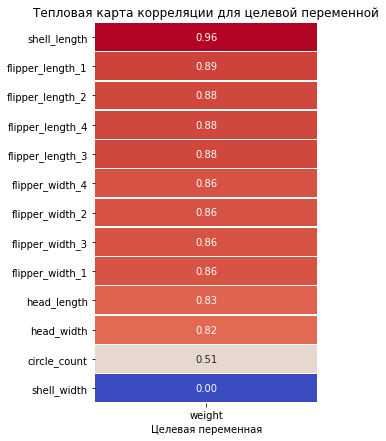

In [18]:
#строим тепловую карту
correlation_matrix = df_unique[['shell_length', 'shell_width', 'head_length', 'head_width', 'flipper_length_1', 
                                'flipper_width_1', 'flipper_length_2', 'flipper_width_2', 'flipper_length_3',
                               'flipper_width_3', 'flipper_length_4', 'flipper_width_4', 'circle_count', 'weight']].phik_matrix()

plt.figure(figsize=(4, 7))

data_heatmap = correlation_matrix.loc[correlation_matrix.index !='weight'][['weight']].sort_values(by='weight', ascending=False)

sns.heatmap(data_heatmap, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5, cbar=False)

plt.title('Тепловая карта корреляции для целевой переменной')
plt.xlabel('Целевая переменная')
plt.show()

In [19]:
print(f'Корреляции с целевой переменной')
print(data_heatmap)

Корреляции с целевой переменной
                    weight
shell_length      0.957884
flipper_length_1  0.888012
flipper_length_2  0.882113
flipper_length_4  0.880172
flipper_length_3  0.879494
flipper_width_4   0.863711
flipper_width_2   0.862955
flipper_width_3   0.860042
flipper_width_1   0.858829
head_length       0.832480
head_width        0.822959
circle_count      0.513872
shell_width       0.000000


Больше всего связь у целевой переменной наблюдается с признаками shell_length и flipper_length_1(0,96 и 0,89). Самая малая взаимосвязь с circle_count(0,51), а с признаком shell_width связь не выявлена вообще. Построим scatterplot, чтобы посмотреть на взаимосвязь

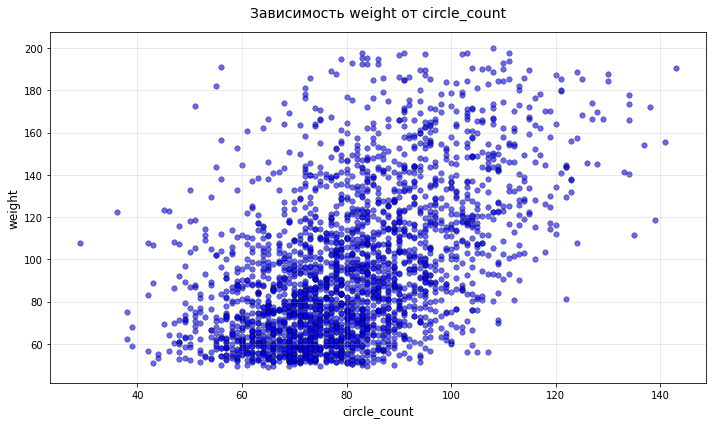

In [20]:
from scipy import stats

plt.figure(figsize=(10, 6))

# Базовый scatter plot
plt.scatter(df_unique['circle_count'], df_unique['weight'], 
            alpha=0.6, s=30, c='blue', edgecolors='black', linewidth=0.5)

plt.title('Зависимость weight от circle_count', fontsize=14, pad=15)
plt.xlabel('circle_count', fontsize=12)
plt.ylabel('weight', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Небольшую взаимосвязь можно увидеть на графике, поэтому оставим circle_count для обучения модели.

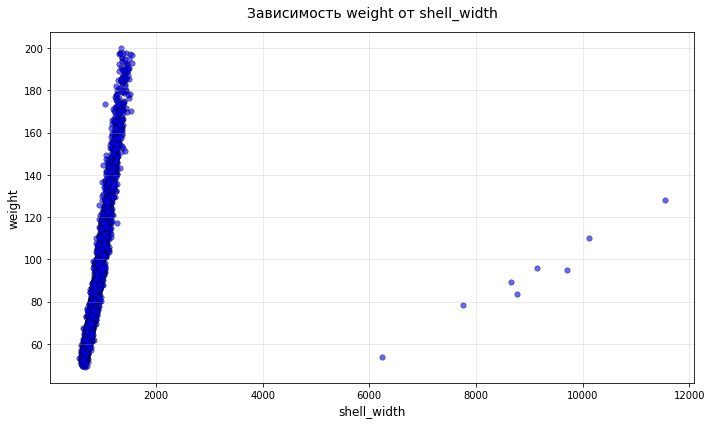

In [21]:
plt.figure(figsize=(10, 6))

# Базовый scatter plot
plt.scatter(df_unique['shell_width'], df_unique['weight'], 
            alpha=0.6, s=30, c='blue', edgecolors='black', linewidth=0.5)

plt.title('Зависимость weight от shell_width', fontsize=14, pad=15)
plt.xlabel('shell_width', fontsize=12)
plt.ylabel('weight', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

График показывает, что поиску взаимосвязи сильно мешают выбросы в данных. Ширина панциря явно должна оказывать хоть какое-то влияние на массу черепахи, так как от нее зависит и площадь панциря, соответственно и размер. Оставим признак для обучения модели и посмотрим на его коэффициенты в дальнейшем.

**4.9 Проверка на мультиколлинеарность**

По тепловой карте видно, что показатели flipper_length_1, flipper_length_2, flipper_length_3, flipper_length_4 имеют одинаковую по силе связь с целевой переменной(0,88). По описанию данных можно понять, что признаки отражают примерно одинаковые показатели, а значит они мультиколлинеарны. Можно избавиться от признаков flipper_length_2, flipper_length_3, flipper_length_4. 
Тоже самое можно сказать о flipper_width_1, flipper_width_2, flipper_width_3, flipper_width_4. Их связь с переменной 0,86. Для избежания мультиколлинеарности избавимся от flipper_width_2, flipper_width_3 и flipper_width_4.

In [22]:
#удаляем мультиколлинеарные признаки
columns_to_drop = ['flipper_length_2','flipper_length_3', 'flipper_length_4', 'flipper_width_2','flipper_width_3', 'flipper_width_4']

df_unique = df_unique.drop(columns=columns_to_drop)

df_unique.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2483 entries, 8 to 7840
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   shell_length      2454 non-null   float64
 1   shell_width       2483 non-null   int64  
 2   head_length       2448 non-null   float64
 3   head_width        2448 non-null   float64
 4   flipper_length_1  2483 non-null   int64  
 5   flipper_width_1   2483 non-null   int64  
 6   circle_count      2483 non-null   int64  
 7   weight            2483 non-null   float64
dtypes: float64(4), int64(4)
memory usage: 174.6 KB


**4.10 Общие выводы по исследовательскому анализу данных**

In [23]:
#Считаем количество удаленных данных
df_difference = len(df) - len(df_unique)
df_difference_ratio = round((df_difference/len(df))*100, 2)

print(f'Количество строк после EDA:{len(df_unique)}')
print(f'Количество удаленных данных:{df_difference}')
print(f'Относительное количество удаленных данных:{df_difference_ratio}%')

Количество строк после EDA:2483
Количество удаленных данных:6378
Относительное количество удаленных данных:71.98%


Во время исследовательского анализа было удалено 6378 строк(71.98%). Это нормальное значение, так как датасет был отфильтрован по одному виду черепах(удалено 6032 строки). Также были удалены ненужные для построения модели столбцы: 'id', 'binomial_name', 'registration number', 'measure_count', 'shell_crack', 'timestamp', 'flipper_length_2', 'flipper_length_3', 'flipper_length_4','flipper_width_2', 'flipper_width_3', 'flipper_width_4'. Была проведена проверка на дубликаты(340 строк удалены). По всем значениям были построены ящики с усами и гистограммы. В столбце shell_width были найдены аномальные выбросы и этот признак будет отсортирован по 99-у персентилю после деления на выборки. Также были удалены нулевые значения целевой переменной(3 строки). Для имеющихся признаков была построена тепловая карта, наибольшая взаимосвязь у целевой переменной нашлась у столбцов shell_length, flipper_length_1, меньше всего - circle_count, shell_width. Также данные прошли проверку на мультиколлинеарность и взаимосвязанные признаки были удалены.

## Предобработка данных

1. Разделите данные на выборки: обучающую (60%), валидационную (20%) и тестовую (20%). В реальных проектах стараются писать код предобработки так, чтобы предотвратить утечку данных. Это проще сделать, если сразу поделить данные.
2. Обработайте пропуски. При необходимости заполните их средними (медианными) значениями. Рассчитайте заполнитель только по обучающей выборке: это ещё одно правило для предотвращения утечки.
3. Напишите функцию для стандартизации признаков. Расчёт параметров масштабирования делайте только по обучающей выборке, чтобы не дать утечке ни малейшего шанса.
4. Напишите функцию для нормализации признаков.
5. Подготовьте несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

**5.1 Делим данные на выборки**

In [24]:
#Определяем X и y
X = df_unique.drop(columns='weight')
y = df_unique['weight']
#Делим на выборки
X_val_train, X_test, y_val_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, 
                                                            random_state=RANDOM_STATE)

X_train, X_val, y_train, y_val = train_test_split(X_val_train, y_val_train, 
                                                  test_size=0.25, shuffle=True, 
                                                  random_state=RANDOM_STATE)

**5.2 Обработка пропусков и аномальных значений**

Во время исследовательского анализа данных были выявлены аномальные значения в столбце shell_width. Избавляемся от них после деления данных, чтобы избежать data leakage.

In [25]:
#Рассчитываем персентиль на обучающей выборке
percentile_99_train = X_train['shell_width'].quantile(0.99)

print(f'Порог отсечения (на обучающей выборке): {percentile_99_train:.2f}')

# Обучающая
train_mask = X_train['shell_width'] <= percentile_99_train
X_train_filtered = X_train[train_mask]
y_train = y_train[train_mask]

# Валидационная
val_mask = X_val['shell_width'] <= percentile_99_train
X_val_filtered = X_val[val_mask]
y_val = y_val[val_mask]

# Тестовая
test_mask = X_test['shell_width'] <= percentile_99_train
X_test_filtered = X_test[test_mask]
y_test = y_test[test_mask]

# 5. Считаем статистику
print(f'\nОбучающая выборка:')
print(f'  После: {len(X_train_filtered)}')
print(f'  Удалено: {len(X_train) - len(X_train_filtered)}')

print(f'\nВалидационная выборка:')
print(f'  После: {len(X_val_filtered)}')
print(f'  Удалено: {len(X_val) - len(X_val_filtered)}')

print(f'\nТестовая выборка:')
print(f'  После: {len(X_test_filtered)}')
print(f'  Удалено: {len(X_test) - len(X_test_filtered)}')

Порог отсечения (на обучающей выборке): 1464.60

Обучающая выборка:
  После: 1474
  Удалено: 15

Валидационная выборка:
  После: 493
  Удалено: 4

Тестовая выборка:
  После: 495
  Удалено: 2


In [26]:
#Заполняем пропуски медианным значением
medians = X_train_filtered.median()

X_train_fill = X_train_filtered.fillna(medians)
X_val_fill = X_val_filtered.fillna(medians)
X_test_fill = X_test_filtered.fillna(medians)

print(f"Пропусков в X_train_fill: {X_train_fill.isnull().sum().sum()}")
print(f"Пропусков в X_val_fill: {X_val_fill.isnull().sum().sum()}")
print(f"Пропусков в X_test_fill: {X_test_fill.isnull().sum().sum()}")

Пропусков в X_train_fill: 0
Пропусков в X_val_fill: 0
Пропусков в X_test_fill: 0


**5.3 Функция масштабирования признаков**

Для удобной работы напишем функции для масштабирования признаков.

In [27]:
#Функция масштабирование
def scale_data(X_train, X_val, X_test, method='standard'):
    if method == 'standard':
        scaler = StandardScaler()
    elif method == 'minmax':
        scaler = MinMaxScaler()
    else:
        raise ValueError("Неверный метод масштабирования. Используйте 'standard' или 'minmax'")
    #Обучаем только на обучающих данных   
    X_train_scaled = scaler.fit_transform(X_train)
    
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    return X_train_scaled, X_val_scaled, X_test_scaled

**5.4 Подготовка датасетов**

По условию задания нужно подготовить несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

In [28]:
#Без масштабирования будут X_train_fill, X_val_fill, X_test_fill
#Со стандартизацией:
X_train_standard, X_val_standard, X_test_standard = scale_data(X_train_fill, X_val_fill, X_test_fill, method='standard')
#С minmax:
X_train_minmax, X_val_minmax, X_test_minmax = scale_data(X_train_fill, X_val_fill, X_test_fill, method='minmax')

**5.5 Общие выводы после предобработки данных**

Во время предобработки данных было сформировано три выборки: обучающая(60%), валидационная(20%) и тестовая(20%). По данным обучающей выборки были заполнены пропуски во всех выборках, чтобы избежать утечки данных. Была написана функция для масштабирования признаков и подготовлены несколько датасетов из трёх выборок каждый для дальнейшего обучения моделей с разным способом масштабирования: без масштабирования, с нормализацией, со стандартизацией.

## Обучение моделей

1. Постройте базовую модель (дамми), с которой будете сравнивать все остальные. Если они будут хуже базовой по качеству, это будет означать, что при обучении что-то пошло не так. Пример дамми: модель, которая всегда предсказывает среднее значение целевой переменной из обучающей выборки.
2. Обучите несколько архитектур линейных моделей. Они могут различаться по ряду черт: набором отобранных признаков, масштабом признаков, установленными гиперпараметрами, функциями потерь. Попробуйте обучить следующие модели:
   - `LinearRegression`;
   - `Lasso` (L1-регуляризация);
   - `Ridge` (L2-регуляризация);
   - `SGDRegressor`.
   
   Обязательно попробуйте модели с разными значениями гиперпараметра `loss`.
- **Бонусное задание.** Подумайте, можно ли улучшить модели за счёт создания новых признаков: например, умножив длину ласт на ширину. Проверьте, усилится ли корреляция нового признака с целевой переменной, возрастёт ли благодаря ему качество модели.
3. Сформируйте итоговую таблицу с результатами моделей. Это удобно сделать в виде датафрейма pandas. Включите в таблицу следующие столбцы:
   - Название модели.
   - Название датасета — оно должно указывать на то, какой способ масштабирования использовался при подготовке данных.
   - Метрики качества, рассчитанные на валидационной выборке. Основная метрика — MAE, дополнительные — MSE, R², MAPE и прочие.

**6.1 Функция для расчета метрик**

Перед начало работы напишем функцию для расчета метрик, чтобы упростить работу в будущем.

In [29]:
#Функция расчета метрик
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'MAE': round(mae, 2),
        'MSE': round(mse, 2),
        'MAPE': round(mape * 100, 2),
        'R2': round(r2, 3)}

In [30]:
#Создадим список для хранения результатов моделей в будущем
results_list = []

**6.2 Построение dummy модели**

In [31]:
#Строим базовую модель(Dummy)
dummy_model = DummyRegressor(strategy='mean')

dummy_model.fit(X_train_fill, y_train)

#Предсказываем
y_pred_dummy = dummy_model.predict(X_train_fill)

#Смотрим метрики
dummy_metrics = calculate_metrics(y_train, y_pred_dummy)

print('Метрики на dummy:', dummy_metrics)

Метрики на dummy: {'MAE': 27.96, 'MSE': 1157.43, 'MAPE': 32.02, 'R2': 0.0}


Базовая модель имеет следующие метрики: MAE: 27.96, MSE: 1157.43, MAPE: 32.02, R2: 0.00. Метрика MAE показывает, что модель в среднем ошибается на 27.96 абсолютных единиц, что достаточно много, учитывая размеры данных(максимальное значение в данных = 200). В среднем процент ошибки составляет 32.02, это означает, что модель достаточно часто ошибается. Метрика R2 = 0.00 говорит о том, что модель работает также, как просто предсказание среднего веса. При создании следующих моделей нужно смотреть, чтобы метрики не были хуже, чем метрики данной модели.

In [32]:
#Добавляем информацию в список
results_list.append({
    'Название модели': 'Dummy',
    'Название датасета': 'Без масштабирования',
    'MAE': round(dummy_metrics['MAE'], 2),
    'MSE': round(dummy_metrics['MSE'], 2),
    'MAPE': round(dummy_metrics['MAPE'], 2),
    'R²': round(dummy_metrics['R2'], 2)
})

**6.3 LinearRegression**

In [33]:
#Обучим модель LinearRegression
linreg = LinearRegression()

linreg.fit(X_train_fill, y_train)
y_pred_linreg = linreg.predict(X_train_fill)

linreg_metrics = calculate_metrics(y_train, y_pred_linreg)

#Выводим метрики
print('Метрики на LinearRegression:', linreg_metrics)

Метрики на LinearRegression: {'MAE': 3.97, 'MSE': 27.68, 'MAPE': 4.42, 'R2': 0.976}


Метрики линейной регресии показывают хорошие результаты. Модель ошибается меньше чем на 5 кг, что соответствует запросу заказчика. В среднем модель ошибается на 4.42%, что тоже показывает хорошие значения на обучающих данных. Модель объясняет 98% данных.

In [34]:
#Добавляем данные в список
results_list.append({
    'Название модели': 'LinearRegression',
    'Название датасета': 'Без масштабирования',
    'MAE': round(linreg_metrics['MAE'], 2),
    'MSE': round(linreg_metrics['MSE'], 2),
    'MAPE': round(linreg_metrics['MAPE'], 2),
    'R²': round(linreg_metrics['R2'], 2)
})

**6.4 SGDRegresor**

In [35]:
#Параметры для SGDRegressor MAE
param_grid_mae = {
    'alpha': np.logspace(-4, 0, 5),
    'learning_rate': ['optimal', 'adaptive'],
    'eta0': [0.001, 0.01],
    'max_iter':[5000]
}

In [36]:
#SGDRegressor с MAE
#Без масштабирования
sgd_mae = SGDRegressor(loss='epsilon_insensitive', epsilon=0.0,
                      random_state=RANDOM_STATE)
grid_mae_original = GridSearchCV(sgd_mae, param_grid_mae, cv=5,
                                scoring = 'neg_mean_absolute_error',
                                n_jobs=-1, verbose=1)
grid_mae_original.fit(X_train_fill, y_train)
best_mae_original = grid_mae_original.best_estimator_
y_pred_sgd_mae_original_val = best_mae_original.predict(X_val_fill)
sgd_mae_original_metrics_val = calculate_metrics(y_val, y_pred_sgd_mae_original_val)

#Со стандартизацией
sgd_mae = SGDRegressor(loss='epsilon_insensitive', epsilon=0.0,
                      random_state=RANDOM_STATE)
grid_mae_standard = GridSearchCV(sgd_mae, param_grid_mae, cv=5,
                                scoring = 'neg_mean_absolute_error',
                                n_jobs=-1, verbose=1)
grid_mae_standard.fit(X_train_standard, y_train)
best_mae_standard = grid_mae_standard.best_estimator_
y_pred_sgd_mae_standard_val = best_mae_standard.predict(X_val_standard)
sgd_mae_standard_metrics_val = calculate_metrics(y_val, y_pred_sgd_mae_standard_val)

#Minmax
sgd_mae = SGDRegressor(loss='epsilon_insensitive', epsilon=0.0,
                      random_state=RANDOM_STATE)
grid_mae_minmax = GridSearchCV(sgd_mae, param_grid_mae, cv=5,
                                scoring = 'neg_mean_absolute_error',
                                n_jobs=-1, verbose=1)
grid_mae_minmax.fit(X_train_minmax, y_train)
best_mae_minmax = grid_mae_minmax.best_estimator_
y_pred_sgd_mae_minmax_val = best_mae_minmax.predict(X_val_minmax)
sgd_mae_minmax_metrics_val = calculate_metrics(y_val, y_pred_sgd_mae_minmax_val)

print('Метрики с MAE без масштабирования:', sgd_mae_original_metrics_val)
print('Метрики с MAE со стандартизацией:', sgd_mae_standard_metrics_val)
print('Метрики с MAE с минмакс:', sgd_mae_minmax_metrics_val)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Метрики с MAE без масштабирования: {'MAE': 10.51, 'MSE': 197.87, 'MAPE': 10.54, 'R2': 0.846}
Метрики с MAE со стандартизацией: {'MAE': 4.16, 'MSE': 33.57, 'MAPE': 4.42, 'R2': 0.974}
Метрики с MAE с минмакс: {'MAE': 4.25, 'MSE': 32.92, 'MAPE': 4.54, 'R2': 0.974}


Хуже всего себя показывает модель с данными без масштабирования(основная метрика=10.51). Лучше всего себя проявляет модель со стандартизацией(MAE=4.16).

In [37]:
#Добавляем данные в список
sgd_mae_configs = [
    ('Без масштабирования', sgd_mae_original_metrics_val),
    ('Стандартизация', sgd_mae_standard_metrics_val),
    ('MinMax', sgd_mae_minmax_metrics_val)
]

for dataset_name, metrics in sgd_mae_configs:
    results_list.append({
        'Название модели': 'SGDRegressor (MAE)',
        'Название датасета': dataset_name,
        'MAE': round(metrics['MAE'], 2),
        'MSE': round(metrics['MSE'], 2),
        'MAPE': round(metrics['MAPE'], 2),
        'R²': round(metrics['R2'], 2)
    })

In [38]:
#Параметры для SGDRegressor MSE
param_grid_mse = {
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'learning_rate': ['adaptive'],
    'eta0': [0.001, 0.01],
    'max_iter':[20000],
    'tol': [1e-5]
}

In [39]:
#SGDRegressor с MSE
#Без масштабирования
sgd_mse = SGDRegressor(loss='squared_loss',
                      random_state=RANDOM_STATE)
grid_mse_original = GridSearchCV(sgd_mse, param_grid_mse, cv=5,
                                scoring = 'neg_mean_squared_error',
                                n_jobs=-1, verbose=1)
grid_mse_original.fit(X_train_fill, y_train)
best_mse_original = grid_mse_original.best_estimator_
y_pred_sgd_mse_original_val = best_mse_original.predict(X_val_fill)
sgd_mse_original_metrics_val = calculate_metrics(y_val, y_pred_sgd_mse_original_val)

#Со стандартизацией
sgd_mse = SGDRegressor(loss='squared_loss',
                      random_state=RANDOM_STATE)
grid_mse_standard = GridSearchCV(sgd_mse, param_grid_mse, cv=5,
                                scoring = 'neg_mean_squared_error',
                                n_jobs=-1, verbose=1)
grid_mse_standard.fit(X_train_standard, y_train)
best_mse_standard = grid_mse_standard.best_estimator_
y_pred_sgd_mse_standard_val = best_mse_standard.predict(X_val_standard)
sgd_mse_standard_metrics_val = calculate_metrics(y_val, y_pred_sgd_mse_standard_val)

#Minmax
sgd_mse = SGDRegressor(loss='squared_loss',
                      random_state=RANDOM_STATE)
grid_mse_minmax = GridSearchCV(sgd_mse, param_grid_mse, cv=5,
                                scoring = 'neg_mean_squared_error',
                                n_jobs=-1, verbose=1)
grid_mse_minmax.fit(X_train_minmax, y_train)
best_mse_minmax = grid_mse_minmax.best_estimator_
y_pred_sgd_mse_minmax_val = best_mse_minmax.predict(X_val_minmax)
sgd_mse_minmax_metrics_val = calculate_metrics(y_val, y_pred_sgd_mse_minmax_val)

print('Метрики с MSE без масштабирования:', sgd_mse_original_metrics_val)
print('Метрики с MSE со стандартизацией:', sgd_mse_standard_metrics_val)
print('Метрики с MSE с минмакс:', sgd_mse_minmax_metrics_val)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Метрики с MSE без масштабирования: {'MAE': 3245802865.13, 'MSE': 1.4233201863884186e+19, 'MAPE': 4256274863.48, 'R2': -1.1083434564975592e+16}
Метрики с MSE со стандартизацией: {'MAE': 4.16, 'MSE': 30.8, 'MAPE': 4.58, 'R2': 0.976}
Метрики с MSE с минмакс: {'MAE': 4.18, 'MSE': 30.76, 'MAPE': 4.6, 'R2': 0.976}


Хуже всего на обучающей выборке SGDRegressor с потерей MSE показываются метрики без масштабирования(R2 = -1.11). Лучше всего себя показывают метрики со стандартизацией, ошибка в абсолютных единицах составляет 4,16 кг.

In [40]:
#Добавляем данные в список
sgd_mse_configs = [
    ('Без масштабирования', sgd_mse_original_metrics_val),
    ('Стандартизация', sgd_mse_standard_metrics_val),
    ('MinMax', sgd_mse_minmax_metrics_val)
]

for dataset_name, metrics in sgd_mse_configs:
    results_list.append({
        'Название модели': 'SGDRegressor (MSE)',
        'Название датасета': dataset_name,
        'MAE': round(metrics['MAE'], 2),
        'MSE': round(metrics['MSE'], 2),
        'MAPE': round(metrics['MAPE'], 2),
        'R²': round(metrics['R2'], 2)
    })

**6.5 Lasso и Ridge**

In [41]:
#Автоматический подбор alpha
alpha_grid = np.logspace(-5, 5, 20)

#Ridge
#Без масштабирования
ridge_cv_original = RidgeCV(alphas=alpha_grid, 
                            scoring='neg_mean_squared_error',
                           cv=5)
ridge_cv_original.fit(X_train_fill, y_train)
best_alpha_original = ridge_cv_original.alpha_
y_pred_ridge_original_val = ridge_cv_original.predict(X_val_fill)
ridge_original_metrics_val = calculate_metrics(y_val, y_pred_ridge_original_val)

print(f'Ridge без масштабирования, лучшая alpha = {best_alpha_original}')
print('Все метрики:', ridge_original_metrics_val)

#Стандартизация
ridge_cv_standard = RidgeCV(alphas=alpha_grid, 
                            scoring='neg_mean_squared_error', 
                            cv=5)
ridge_cv_standard.fit(X_train_standard, y_train)
best_alpha_standard = ridge_cv_standard.alpha_
y_pred_ridge_standard_val = ridge_cv_standard.predict(X_val_standard)
ridge_standard_metrics_val = calculate_metrics(y_val, y_pred_ridge_standard_val)

print(f'\nRidge со стандартизацией, лучшая alpha = {best_alpha_standard}')
print('Все метрики:', ridge_standard_metrics_val)

#Minmax
ridge_cv_minmax = RidgeCV(alphas=alpha_grid, 
                          scoring='neg_mean_squared_error', 
                          cv=5)
ridge_cv_minmax.fit(X_train_minmax, y_train)
best_alpha_minmax = ridge_cv_minmax.alpha_
y_pred_ridge_minmax_val = ridge_cv_minmax.predict(X_val_minmax)
ridge_minmax_metrics_val = calculate_metrics(y_val, y_pred_ridge_minmax_val)

print(f'\nRidge с минмакс, лучшая alpha = {best_alpha_minmax}')
print('Все метрики:', ridge_minmax_metrics_val)

Ridge без масштабирования, лучшая alpha = 29763.51441631313
Все метрики: {'MAE': 4.15, 'MSE': 30.92, 'MAPE': 4.57, 'R2': 0.976}

Ridge со стандартизацией, лучшая alpha = 1.8329807108324339
Все метрики: {'MAE': 4.15, 'MSE': 30.9, 'MAPE': 4.57, 'R2': 0.976}

Ridge с минмакс, лучшая alpha = 0.1623776739188721
Все метрики: {'MAE': 4.15, 'MSE': 30.88, 'MAPE': 4.57, 'R2': 0.976}


In [42]:
#Добавляем данные в список
ridge_configs = [
    ('Без масштабирования', ridge_original_metrics_val, best_alpha_original),
    ('Стандартизация', ridge_standard_metrics_val, best_alpha_standard),
    ('MinMax', ridge_minmax_metrics_val, best_alpha_minmax)
]

for dataset_name, metrics, best_alpha in ridge_configs:
    results_list.append({
        'Название модели': f'Ridge (alpha={best_alpha:.2e})',
        'Название датасета': dataset_name,
        'MAE': round(metrics['MAE'], 2),
        'MSE': round(metrics['MSE'], 2),
        'MAPE': round(metrics['MAPE'], 2),
        'R²': round(metrics['R2'], 2)
    })

In [43]:
#Перебор значений для Lasso
alpha_grid_lasso = np.logspace(-8, 3, 30)

lasso_cv_original = LassoCV(alphas=alpha_grid_lasso, 
                            random_state=RANDOM_STATE,
                           cv=5, max_iter=10000)
lasso_cv_original.fit(X_train_fill, y_train)
best_alpha_lasso_original = lasso_cv_original.alpha_
y_pred_lasso_original_val = lasso_cv_original.predict(X_val_fill)
lasso_original_metrics_val = calculate_metrics(y_val, y_pred_lasso_original_val)

print(f"\nLasso без масштабирования, лучшая alpha = {best_alpha_lasso_original}")
print('Все метрики:', lasso_original_metrics_val)

#Со стандартизацией
lasso_cv_standard = LassoCV(alphas=alpha_grid_lasso, 
                            random_state=RANDOM_STATE, 
                            cv=5, max_iter=10000)
lasso_cv_standard.fit(X_train_standard, y_train)
best_alpha_lasso_standard = lasso_cv_standard.alpha_
y_pred_lasso_standard_val = lasso_cv_standard.predict(X_val_standard)
lasso_standard_metrics_val = calculate_metrics(y_val, y_pred_lasso_standard_val)

print(f"\nLasso со стандартизацией, лучшая alpha = {best_alpha_lasso_standard}")
print('Все метрики:', lasso_standard_metrics_val)

#Minmax
lasso_cv_minmax = LassoCV(alphas=alpha_grid_lasso, 
                          random_state=RANDOM_STATE, cv=5, max_iter=10000)
lasso_cv_minmax.fit(X_train_minmax, y_train)
best_alpha_lasso_minmax = lasso_cv_minmax.alpha_
y_pred_lasso_minmax_val = lasso_cv_minmax.predict(X_val_minmax)
lasso_minmax_metrics_val = calculate_metrics(y_val, y_pred_lasso_minmax_val)

print(f"\nLasso с минмакс, лучшая alpha = {best_alpha_lasso_minmax}")
print('Все метрики:', lasso_minmax_metrics_val)


Lasso без масштабирования, лучшая alpha = 0.16102620275609392
Все метрики: {'MAE': 4.15, 'MSE': 30.92, 'MAPE': 4.57, 'R2': 0.976}

Lasso со стандартизацией, лучшая alpha = 0.011721022975334793
Все метрики: {'MAE': 4.15, 'MSE': 30.92, 'MAPE': 4.56, 'R2': 0.976}

Lasso с минмакс, лучшая alpha = 0.0008531678524172797
Все метрики: {'MAE': 4.15, 'MSE': 30.92, 'MAPE': 4.56, 'R2': 0.976}


Метрики Lasso и Ridge показали одинаковые результаты на всех трех датасетах. MAE=4.15, что соотвествует запросу заказчика. Модели показывают хорошие метрики.

In [44]:
#Добавляем данные в список
lasso_configs = [
    ('Без масштабирования', lasso_original_metrics_val, best_alpha_lasso_original),
    ('Стандартизация', lasso_standard_metrics_val, best_alpha_lasso_standard),
    ('MinMax', lasso_minmax_metrics_val, best_alpha_lasso_minmax)
]

for dataset_name, metrics, best_alpha in lasso_configs:
    results_list.append({
        'Название модели': f'Lasso (alpha={best_alpha:.2e})',
        'Название датасета': dataset_name,
        'MAE': round(metrics['MAE'], 2),
        'MSE': round(metrics['MSE'], 2),
        'MAPE': round(metrics['MAPE'], 2),
        'R²': round(metrics['R2'], 2)
    })

**6.6 Создание таблицы**

In [45]:
results_df = pd.DataFrame(results_list)

# Сортируем по MAE для удобства сравнения
results_df = results_df.sort_values('MAE').reset_index(drop=True)

# Настраиваем отображение чисел в нормальном формате (не экспоненциальном)
pd.set_option('display.float_format', '{:.2f}'.format)

# Выводим таблицу
print(results_df.to_string(
    index=False,
    justify='left',
    col_space={'Название модели': 30, 'Название датасета': 18, 'MAE': 8, 'MSE': 12, 'MAPE': 8, 'R²': 8}
))

Название модели                Название датасета    MAE           MSE                     MAPE          R²                  
      LinearRegression         Без масштабирования          3.97                   27.68          4.42                  0.98
Ridge (alpha=2.98e+04)         Без масштабирования          4.15                   30.92          4.57                  0.98
Ridge (alpha=1.83e+00)              Стандартизация          4.15                   30.90          4.57                  0.98
Ridge (alpha=1.62e-01)                      MinMax          4.15                   30.88          4.57                  0.98
Lasso (alpha=1.61e-01)         Без масштабирования          4.15                   30.92          4.57                  0.98
Lasso (alpha=1.17e-02)              Стандартизация          4.15                   30.92          4.56                  0.98
Lasso (alpha=8.53e-04)                      MinMax          4.15                   30.92          4.56                  0.98


**6.7 Общие выводы по обучению моделей**

В ходе обучения моделей была создана функция для удобного расчета метрик, построена базовая модель, рассчитывающая среднее по целевой переменной. Также были обучены модели LinearRegression, Lasso (L1-регуляризация), Ridge (L2-регуляризация), SGDRegressor с разными функциями потерь и гиперпараметрами.Для дальнейшего удобства была создана таблица с обученными моделями.

## Сравнение моделей на валидационной выборке

1. Сравните построенные модели по метрикам на валидационной выборке. Удалось ли существенно улучшить результат базовой модели?
2. Выберите лучшую модель по основной метрике на валидационной выборке. Не заглядывайте в метрики на тестовой выборке раньше времени. Тестовая выборка не используется для обучения моделей, подбора гиперпараметров и сравнения моделей с разными значениями.
3. Напишите выводы о том, какая из моделей обладает лучшим качеством. Именно её одну далее нужно проверить на тестовой выборке для итоговой оценки.

**7.1 Сравниваем модели на валидационной выборке**

In [46]:
#базовая модель
y_pred_dummy_val = dummy_model.predict(X_val_fill)
dummy_metrics_val = calculate_metrics(y_val, y_pred_dummy_val)

#LinearRegression
y_pred_linreg_val = linreg.predict(X_val_fill)
linreg_metrics_val = calculate_metrics(y_val, y_pred_linreg_val)

print("Результаты оценки моделей по валидационной выборке")

print(f"\nDUMMY:               {dummy_metrics_val}")
print(f"LinearRegression:    {linreg_metrics_val}")

Результаты оценки моделей по валидационной выборке

DUMMY:               {'MAE': 29.07, 'MSE': 1288.74, 'MAPE': 32.16, 'R2': -0.004}
LinearRegression:    {'MAE': 4.15, 'MSE': 30.91, 'MAPE': 4.57, 'R2': 0.976}


После проверки на валидационной выборке модели ухудшили свои результаты, но на минимальные значения, что говорит о правильном обучении модели.

In [47]:
# Создаем список всех моделей с их названиями и метриками
models_list = [
    ('Dummy', dummy_metrics_val),
    ('LinearRegression', linreg_metrics_val),
    ('SGD_MAE_Original', sgd_mae_original_metrics_val),
    ('SGD_MAE_Standard', sgd_mae_standard_metrics_val),
    ('SGD_MAE_MinMax', sgd_mae_minmax_metrics_val),
    ('SGD_MSE_Original', sgd_mse_original_metrics_val),
    ('SGD_MSE_Standard', sgd_mse_standard_metrics_val),
    ('SGD_MSE_MinMax', sgd_mse_minmax_metrics_val),
    ('Ridge_Original', ridge_original_metrics_val),
    ('Ridge_Standard', ridge_standard_metrics_val),
    ('Ridge_MinMax', ridge_minmax_metrics_val),
    ('Lasso_Original', lasso_original_metrics_val),
    ('Lasso_Standard', lasso_standard_metrics_val),
    ('Lasso_MinMax', lasso_minmax_metrics_val)
]

best_model_name = None
best_mae = float('inf')
best_model_metrics = None

for model_name, metrics in models_list:
    mae = metrics['MAE']
    mse = metrics['MSE']
    
    print(f"{model_name:<35} {mae:>10.4f} {mse:>12.4f}")
    
    # Сравниваем сначала по MAE, если равны, то по MSE
    if mae < best_mae:
        best_mae = mae
        best_mse = mse
        best_model_name = model_name
        best_model_metrics = metrics
    elif mae == best_mae and mse < best_mse:
        best_mse = mse
        best_model_name = model_name
        best_model_metrics = metrics

print(f"\nЛучшая модель по MAE(MSE): {best_model_name}")

# Выводим все метрики лучшей модели
print(f"\nВсе метрики для лучшей модели:")
for metric_name, value in best_model_metrics.items():
    print(f"  {metric_name}: {value:.4f}")

Dummy                                  29.0700    1288.7400
LinearRegression                        4.1500      30.9100
SGD_MAE_Original                       10.5100     197.8700
SGD_MAE_Standard                        4.1600      33.5700
SGD_MAE_MinMax                          4.2500      32.9200
SGD_MSE_Original                    3245802865.1300 14233201863884185600.0000
SGD_MSE_Standard                        4.1600      30.8000
SGD_MSE_MinMax                          4.1800      30.7600
Ridge_Original                          4.1500      30.9200
Ridge_Standard                          4.1500      30.9000
Ridge_MinMax                            4.1500      30.8800
Lasso_Original                          4.1500      30.9200
Lasso_Standard                          4.1500      30.9200
Lasso_MinMax                            4.1500      30.9200

Лучшая модель по MAE(MSE): Ridge_MinMax

Все метрики для лучшей модели:
  MAE: 4.1500
  MSE: 30.8800
  MAPE: 4.5700
  R2: 0.9760


Много моделей показывали одинаковые MAE на валидационной выборке, поэтому второй метрикой сравнения была выбрана MSE. Итого лучшей модель оказалась Ridge с датасетом с нормализацией минмакс. В среднем модель откланяется на 4.15 абсолютные единицы, что все еще соответствует требованиям заказчика(не больше 5 кг). В среднем модель откланяется на 4,57% и предсказывает 98% данных. Метрики модели показали очень хорошие результаты и лучшие среди имющихся моделей, поэтому именно на этой моделе будет проверяться тестовая выборка.

## Проверка лучшей модели на тестовой выборке

1. Проверьте метрики лучшей модели на тестовой выборке.
2. Узнайте, есть ли признаки переобучения лучшей модели.
3. Определите, соответствует ли модель требованиям заказчика. Объясните, можно ли её рекомендовать к внедрению.

In [48]:
#Проверка модели на тестовой выборке
y_pred_ridge_minmax_test = ridge_cv_minmax.predict(X_test_minmax)
ridge_minmax_metrics_test = calculate_metrics(y_test, y_pred_ridge_minmax_test)

y_pred_ridge_minmax_train = ridge_cv_minmax.predict(X_train_minmax)
ridge_minmax_metrics_train = calculate_metrics(y_train, y_pred_ridge_minmax_train)

print('Метрики на обучающей выборке:', ridge_minmax_metrics_train)
print('\nМетрики на валидационной выборке:', ridge_minmax_metrics_val)
print('\nМетрики на тестовой выборке:', ridge_minmax_metrics_test)

Метрики на обучающей выборке: {'MAE': 3.98, 'MSE': 27.68, 'MAPE': 4.42, 'R2': 0.976}

Метрики на валидационной выборке: {'MAE': 4.15, 'MSE': 30.88, 'MAPE': 4.57, 'R2': 0.976}

Метрики на тестовой выборке: {'MAE': 4.07, 'MSE': 30.23, 'MAPE': 4.35, 'R2': 0.975}


Модель показала хорошие результаты на всех выборках. Все показатели находятся в примерно одинаковых значениях, а значит модель обучена хорошо. На тестовой выборке основная метрика показывает 4.07 кг, что не превышает 5 кг, а значит модель можно рекомендовать к внедрению, ведь она достигла основной метрики без утечки данных.

## Оценка важности признаков

1. Оцените важность признаков по абсолютным значениям весов лучшей модели.
2. Напишите, какие признаки стали для модели более важными. Объясните, согласны ли вы с таким результатом?

In [49]:
#Оцениваем важность признаков
best_lasso = ridge_cv_minmax

coefficients = best_lasso.coef_

#Берем названия признаков
feature_names = X_train_fill.columns

#Создаем DataFrame
importance = pd.DataFrame({
    'feature':feature_names,
    'coefficient':coefficients})

importance = importance.sort_values('coefficient', ascending=False)

print(f"\nВсе признаки с коэффициентами:")
for idx, row in importance.iterrows():
    print(f"{row['feature']:20} {row['coefficient']:10.2f}")


Все признаки с коэффициентами:
shell_length              65.48
shell_width               43.64
flipper_length_1          25.71
flipper_width_1           15.74
head_width                13.71
head_length               12.58
circle_count               2.37


Самыми важными признаками для модели стали длина и ширина панциря. Эти параметры вполне обоснованы, ведь по площади панциря можно понять размеры черепахи и соответственно её вес. Остальные важные признаки: длина и ширина ласт, длина и ширина головы - также показывают размер черепахи, от которого зависит и ее вес. Наименее важным признаком стало количество колец, что тоже обосновано, ведь количество колец коррелирует с возрастом черепахи, а возраст в некоторой степени с размером. Но кольца у черепах могут появляться не сразу и это не является прямым фактором.

## Функция для прогнозирования веса черепахи

* Напишите на Python функцию, которая будет прогнозировать массу черепахи по заданным параметрам с учётом коэффициентов лучшей модели (свойство `coef_`) и смещения (свойство `intercept_`).
* Если вы столкнётесь с трудностями при написании функции, то представьте, что обращаетесь к старшему коллеге с просьбой помочь, и составьте задание для её написания. Подробно опишите логику, по которой рассчитывается масса черепахи, и укажите, как именно должны происходить расчёты.

In [50]:
#Функция для прогнозирования веса черепахи
def turtle_weight_function(shell_length, shell_width, flipper_length_1, 
                           flipper_width_1, head_width, head_length, 
                           circle_count, model, scaler):
    
    # Собираем все признаки в массив
    features = np.array([shell_length, shell_width, flipper_length_1, 
                         flipper_width_1, head_width, head_length, circle_count])
    #Стандартизируем данные
    features_scaled = scaler.transform(features.reshape(1, -1))
    
    prediction = model.predict(features_scaled)
    
    return prediction[0]

## Общие выводы и рекомендации по дальнейшей работе

Напишите общие выводы и рекомендации по дальнейшей работе. Ответьте на вопросы:
  - Какие модели изучены?
  - Какие результаты получены?
  - Рекомендуется ли итоговая модель к внедрению?
  - Какая архитектура и способ обработки признаков показали себя лучше всего? Какие у них показатели метрик?
  - Какие признаки наиболее важны для модели?
  - Есть ли перспективы у обучения этой или других моделей для предсказания массы других видов черепах?
  - При наличии добавьте сюда свои предложения по дальнейшему развитию проекта.

**11.1 Проделанная работа**

   Во время реализации проекта был проведен исследовательский анализ данных. Были исправлены ошибки в данных. Значения длины панциря, которые были случайно умножены на 10, больше 3000 мм были поделены на 10, так как значения выше являются аномальной для черепах и считаются ошибкой. Также датасет был отфильтрован по виду черепах(Chelonia Mydas), для изучения конкретного вида.
   
   Для дальнейшего обучения модели были удалены столбцы никак не коррелирующие с целевой переменной или те, которые могли давать ложную корреляцию: id, binomial_name, registration_number, measure_count, shell_crack, timestamp.
   
   Также были удалены пропуски в целевой переменной и значения с нулями, которые могли помешать работе модели. Датасет также прошел проверку на дубликаты и было удалено 340 строк(12.03%). Все данные прошли проверку на выбросы и были очищены от возможных аномальных значений.
   
   После построения тепловой карты максимальная связь целевой переменной нашлась у показателей длины и ширины панциря, а также была выявлена мультиколлинеарность признаков длины и ширины ластов, которая была удалена.
   
   Во время предобработки данных были созданы три выборки: обучающая(60%), валидационная(20%) и тестовая(20%). Пропуски данных были обработаны по обучающей выборке, чтобы избежать утечки данных. Также данные были масштабированы и появилось 3 датасета: данные без масштабирования, со стандартизацией и с нормализацией.

   Во время работы были обучены несколько моделей: базовая модель(Dummy), LinearRegression, SGDRegressor(loss=MAE), SGDRegressor(loss=MSE), Lasso и Ridge. Все модели были обучены на трех датасетах. На тренировочной выборке большинство моделей показали достаточно хорошие результаты. После проверки на валидационной выборке была выявлена лучшая модель - <strong>Ridge с нормализацией</strong>. Она показала среднюю ошибку в абсолютных единицах равную 4.15. В среднем модель ошибается на 4.57% и предсказывает 98% данных. Именно эта модель и проходила проверку на тестовой выборке.
   
   Тестовая выборка показала, что модель соответствует всем запрашиваемым параметрам. Она в среднем ошибается лишь на 4.07кг. По запросу заказчика должно было быть не больше 5 кг ошибки. Метрика R2 показывает, что модель предсказывает 98% данных, что является очень хорошим результатом. Данную модель можно рекомендовать для работы с другими видами черепах.

   В дальнейшем проект можно развить так, чтобы создать модель, самостоятельно предсказывающую вид черепахи и рассчитывающую её массу по моделе конкретного вида. Так процедура станет максимально стандартизированной и не будет требовать предварительного деления людьми черепах на виды.